In [1]:
import wikipediaapi
import nltk
import ssl
import re
import numpy as np
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer #ex for lemmatization runnig > run played > play
from sklearn.feature_extraction.text import TfidfVectorizer #ex for tfidf vectorizer : "the cat is on the roof" => [0, 1, 0, 1, 0, 0, 1, 0] (vector representation of the text)
from sklearn.cluster import KMeans #ex for kmeans : clustering algorithm that groups similar data points together based on their features
from sklearn.metrics import silhouette_score #ex for silhouette score : a measure of how well a data point fits into its assigned cluster compared to other clusters. It ranges from -1 to 1, where a higher score indicates better clustering.
import matplotlib.pyplot as plt

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Now, try to download the data again
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("NLTK data downloaded successfully using the manual method.")

print("Libraries imported and NLTK data downloaded successfully!")

NLTK data downloaded successfully using the manual method.
Libraries imported and NLTK data downloaded successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/shasidu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/shasidu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/shasidu/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [30]:
article_titles = [
"Galaxy","Operating system","Scientific method","Particle physics","Research","Innovation","Technology","Data structure","Enzyme",
"Artificial neural network","Chatbot", "Autonomous vehicle","Drone", "Artificial intelligence","Edge computing","Quantum computing",
"Human-computer interaction","Accessibility","Information security","Malware","Phishing","Digital signature","Cloud security"
]

In [31]:
# --- Step 2: Fetch Wikipedia Articles ---

# List of articles to cluster. We've chosen topics in astronomy, biology, and computer science.
article_titles = [
    "Galaxy", "Black hole", "Supernova", # Astronomy
    "DNA", "Photosynthesis", "Evolution", # Biology
    "Machine learning", "Artificial intelligence", "Computer programming" # Computer Science
]

wiki_api = wikipediaapi.Wikipedia('MyClusteringProject/1.0', 'en')


document = []

for title in article_titles:
    page = wiki_api.page(title)
    if page.exists():
        document.append(page.text)
        print(f"Fetched article: '{title}' with {len(page.text)} characters.")
    else:
        print(f"Article '{title}' not found.")


Fetched article: 'Galaxy' with 50925 characters.
Fetched article: 'Black hole' with 74139 characters.
Fetched article: 'Supernova' with 66143 characters.
Fetched article: 'DNA' with 58674 characters.
Fetched article: 'Photosynthesis' with 49791 characters.
Fetched article: 'Evolution' with 69354 characters.
Fetched article: 'Machine learning' with 58871 characters.
Fetched article: 'Artificial intelligence' with 83583 characters.
Fetched article: 'Computer programming' with 27906 characters.


In [32]:
stop_words = set(stopwords.words('english'))
print("Stop words loaded:", list(stop_words))  # Print first 10 stop words to verify

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    print(f"Lowercased text: {text[:100]}...")  # Print first 100 characters to verify
    
    # Remove punctuation and non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)
    print(f"Cleaned text: {text[:100]}...")  # Print first 100 characters to verify
    
    # Tokenize the text
    words = text.split()
    print(f"words: {words[:10]}...")  # Print first 10 tokens to verify
    
    # Remove stop words and lemmatize
    processed_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    print(f"Processed words: {processed_words[:10]}...")  # Print first 10 processed tokens to verify
    
    return ' '.join(processed_words)

processed_documents = [preprocess_text(doc) for doc in document]
print("Preprocessing completed. Sample processed document:\n", processed_documents[0][:500],"...")  # Print first 500 characters of the first processed document to verify

Stop words loaded: ['only', 'be', 'aren', 'd', 'for', 'through', 'hasn', 'most', 'during', "won't", 'both', 'those', "don't", 'mustn', "mustn't", 'what', 'after', 'has', 'more', "they're", "wouldn't", 'have', 'off', 'are', 'them', 'myself', 'i', 'will', 'itself', 'as', "didn't", 'wasn', 'my', 'who', 'very', 'am', "doesn't", "you'd", 'were', 'you', 'been', 'until', 'should', 'nor', 'if', 'their', 'herself', 're', 'isn', 'doing', 'not', 'out', 'wouldn', 'll', 'themselves', 'doesn', 'before', 'being', 'above', 'do', 'needn', 'me', "you've", 'when', 'his', 'once', 'few', "he'll", 'own', 'where', 'into', 'here', 'than', 'now', 'under', 'him', "mightn't", "i'd", 'himself', 'which', 'up', 'an', 'don', 'so', "i'm", 'each', 'other', 'ain', "it'll", 'all', 'any', 'these', 'y', 'yourself', 'can', 'our', "he's", "needn't", "they've", 'again', 'same', 'shouldn', "they'll", 'because', 't', 'weren', "isn't", 'ourselves', 'such', 'on', "we're", "he'd", "she'll", 'just', "should've", "shouldn't", "we'l

In [33]:
# --- Step 4: Convert Text to Vectors ---

# Initialize the TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=1000) # Limit to the top 1000 features

# Create the TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(processed_documents)

print(tfidf_matrix)

print("TF-IDF matrix created successfully.")
print(f"Shape of the matrix: {tfidf_matrix.shape}")

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5160 stored elements and shape (9, 1000)>
  Coords	Values
  (0, 374)	0.8687166888516529
  (0, 907)	0.011549870226872911
  (0, 868)	0.28772782051137546
  (0, 873)	0.02489952292886903
  (0, 771)	0.004888907552615782
  (0, 465)	0.026888991539386793
  (0, 377)	0.06267767817016977
  (0, 266)	0.02933344531569469
  (0, 211)	0.039111260420926254
  (0, 544)	0.03531787321628897
  (0, 107)	0.008724919944965754
  (0, 933)	0.01175206465690683
  (0, 396)	0.016599681952579354
  (0, 992)	0.005297680982443346
  (0, 548)	0.0021812299862414386
  (0, 568)	0.13556406927939804
  (0, 756)	0.002887467556718228
  (0, 981)	0.07074295513959658
  (0, 190)	0.005297680982443346
  (0, 849)	0.014666722657847344
  (0, 304)	0.008829468304072243
  (0, 569)	0.01588107156195025
  (0, 736)	0.0043312013350773415
  (0, 840)	0.02154545187099586
  (0, 267)	0.05533227317526451
  :	:
  (8, 632)	0.0313097789418164
  (8, 89)	0.006915973533860016
  (8, 717)	0.50095646306

In [40]:
# --- Step 5: Run K-Means ---

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
## The below line is functionally identical to the above line
#kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
kmeans.fit(tfidf_matrix)

# Get the cluster assignments for each document
labels = kmeans.labels_
print(labels)

[2 2 2 0 0 0 1 1 1]


In [42]:
# --- Step 6: Evaluation Model performance ---
# --- 1. Calculate WCSS (Within-Cluster Sum of Squares) ---
# This is already calculated automatically when you fit the model!
# It is stored in the variable 'kmeans.inertia_'
wcss = kmeans.inertia_

# --- 2. Calculate Silhouette Score ---
# This measures how well-separated the clusters are.
# It takes the data (tfidf_matrix) and the labels the model assigned.
sil_score = silhouette_score(tfidf_matrix, kmeans.labels_)

print("--- Model Evaluation Metrics ---")
print(f"WCSS (Inertia): {wcss:.4f}")
print(f"Silhouette Score: {sil_score:.4f}")



--- Model Evaluation Metrics ---
WCSS (Inertia): 4.6122
Silhouette Score: 0.0999


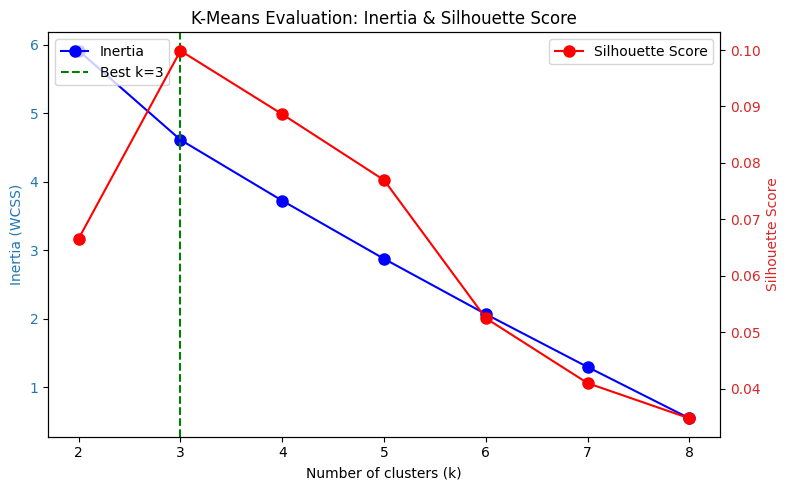

Suggested optimal number of clusters by silhouette score: k = 3


In [43]:
# --- Step 7: Evaluate the optimal number of clusters (k) for K-Means using two metrics ---

# 1. Inertia (WCSS) – measures within-cluster compactness (used in the Elbow method).
# 2. Silhouette Score – measures how well-separated the clusters are.
# The code runs K-Means for different k values, stores both metrics, and plots them
# to help visually identify the best number of clusters.

# Number of documents
num_docs = tfidf_matrix.shape[0]

# --- Step 1: Define range of k ---
k_values = range(2, num_docs)  # 2 to 8

inertia_values = []
silhouette_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(tfidf_matrix)
    inertia_values.append(kmeans.inertia_)
    sil_score = silhouette_score(tfidf_matrix, labels)
    silhouette_values.append(sil_score)

# --- Step 3: Plot both curves ---
fig, ax1 = plt.subplots(figsize=(8,5))

color = 'tab:blue'
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia (WCSS)', color=color)
ax1.plot(k_values, inertia_values, 'bo-', markersize=8, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('K-Means Evaluation: Inertia & Silhouette Score')

# Create second y-axis for silhouette
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_values, silhouette_values, 'ro-', markersize=8, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

# Optional: mark best k according to silhouette
best_k_index = silhouette_values.index(max(silhouette_values))
best_k = k_values[best_k_index]
ax1.axvline(x=best_k, color='green', linestyle='--', label=f'Best k={best_k}')

# Legends
fig.tight_layout()
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

print(f"Suggested optimal number of clusters by silhouette score: k = {best_k}")

In [37]:
# --- Step 8: Putting the Model to Work - Predicting on New Documents ---
# Now for the exciting part! We can take our final "trained" model and
# use it to instantly categorize a brand new, unseen document.
# Let's see which topic cluster it belongs to!

# --- Define your new document ---
new_text = "An algorithm is a set of well-defined instructions designed to perform a specific task or solve a computational problem. In computer science, the study of algorithms is fundamental to creating efficient and scalable software. Data structures, such as arrays and hash tables, are used to organize data in a way that allows these algorithms to access and manipulate it effectively."

# --- Apply the SAME preprocessing ---
# We use the preprocess_text function we defined earlier
processed_new_text = preprocess_text(new_text)
print(f"Cleaned Text: {processed_new_text}")

# --- Use the FITTED vectorizer to transform the text ---
# IMPORTANT: Use .transform(), not .fit_transform()
# This ensures it uses the same vocabulary learned from the original documents.
new_tfidf_vector = vectorizer.transform([processed_new_text])

print(f"\nShape of the new vector: {new_tfidf_vector.shape}")

# --- Now you can predict its cluster ---
predicted_label = kmeans.predict(new_tfidf_vector)

print(f"\nThe new document belongs to cluster: {predicted_label[0]}")

Lowercased text: an algorithm is a set of well-defined instructions designed to perform a specific task or solve a co...
Cleaned text: an algorithm is a set of welldefined instructions designed to perform a specific task or solve a com...
words: ['an', 'algorithm', 'is', 'a', 'set', 'of', 'welldefined', 'instructions', 'designed', 'to']...
Processed words: ['algorithm', 'set', 'welldefined', 'instruction', 'designed', 'perform', 'specific', 'task', 'solve', 'computational']...
Cleaned Text: algorithm set welldefined instruction designed perform specific task solve computational problem computer science study algorithm fundamental creating efficient scalable software data structure array hash table used organize data way allows algorithm access manipulate effectively

Shape of the new vector: (1, 1000)

The new document belongs to cluster: 1
